# Free Space Path Loss

Model the signal loss as the distance increases by modelling it using FSPL equations.

FSPL(dB) = 20log(d) + 20log(f) - 147.55 - Gt - Gr

Where:
- d is the distance from the transmitter
- f is the frequency of the wave, so 24MHz
- Gt is the transmitter's gain
- Gr is the receiver's gain. It's assumed this is 1 as the antenna is isotropic?

References:
- https://en.wikipedia.org/wiki/Free-space_path_loss
- https://www.pasternack.com/t-calculator-fspl.aspx
- https://www.bdamax.com/blog/db-vs-dbm-whats-the-real-difference/

In [15]:
import math

def signal_loss(distance :float, frequency = 2_400_000_000, transmitter_gain = 14, receiver_gain = 1):
    return 20 * math.log10(distance) + 20 * math.log10(frequency) - 147.55  - transmitter_gain - receiver_gain

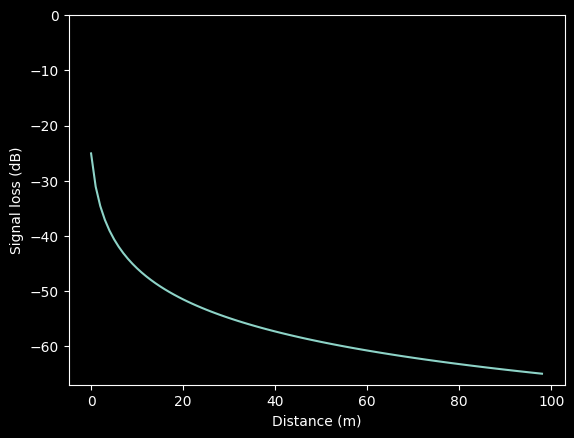

In [21]:
import matplotlib.pyplot as plt

points = []

for x in range (1, 100, 1):
    points.append(signal_loss(x) * - 1)

plt.plot(points)
plt.ylim(ymax=0)
plt.xlabel("Distance (m)")
plt.ylabel("Signal loss (dB)")
plt.show()

## Estimated vs Received Signal Strength

Model what the FSPL equation estimates the RSS should be at a given distance from the transmitter, and compare this to the actual signal strength received by the tag.

Looks at `/March 26 2025 Field Trial/straightpath5/` experiment, where the device moved ~106m.

Known inaccuracies:
- Real `transmitter_power` is unknown, but -6dBm fits the data
- The tag may not have travelled at a constant velocity in a straight line
- The entire dataset is used and it's assumed there are no pauses at the start/end and the tag doesn't retrace its steps

### Conclusion

The attenuation of the BLE signal mildly resemble the model of signal loss using FSPL equations.

Standardising angles and times (shifting by 0.00 degrees)


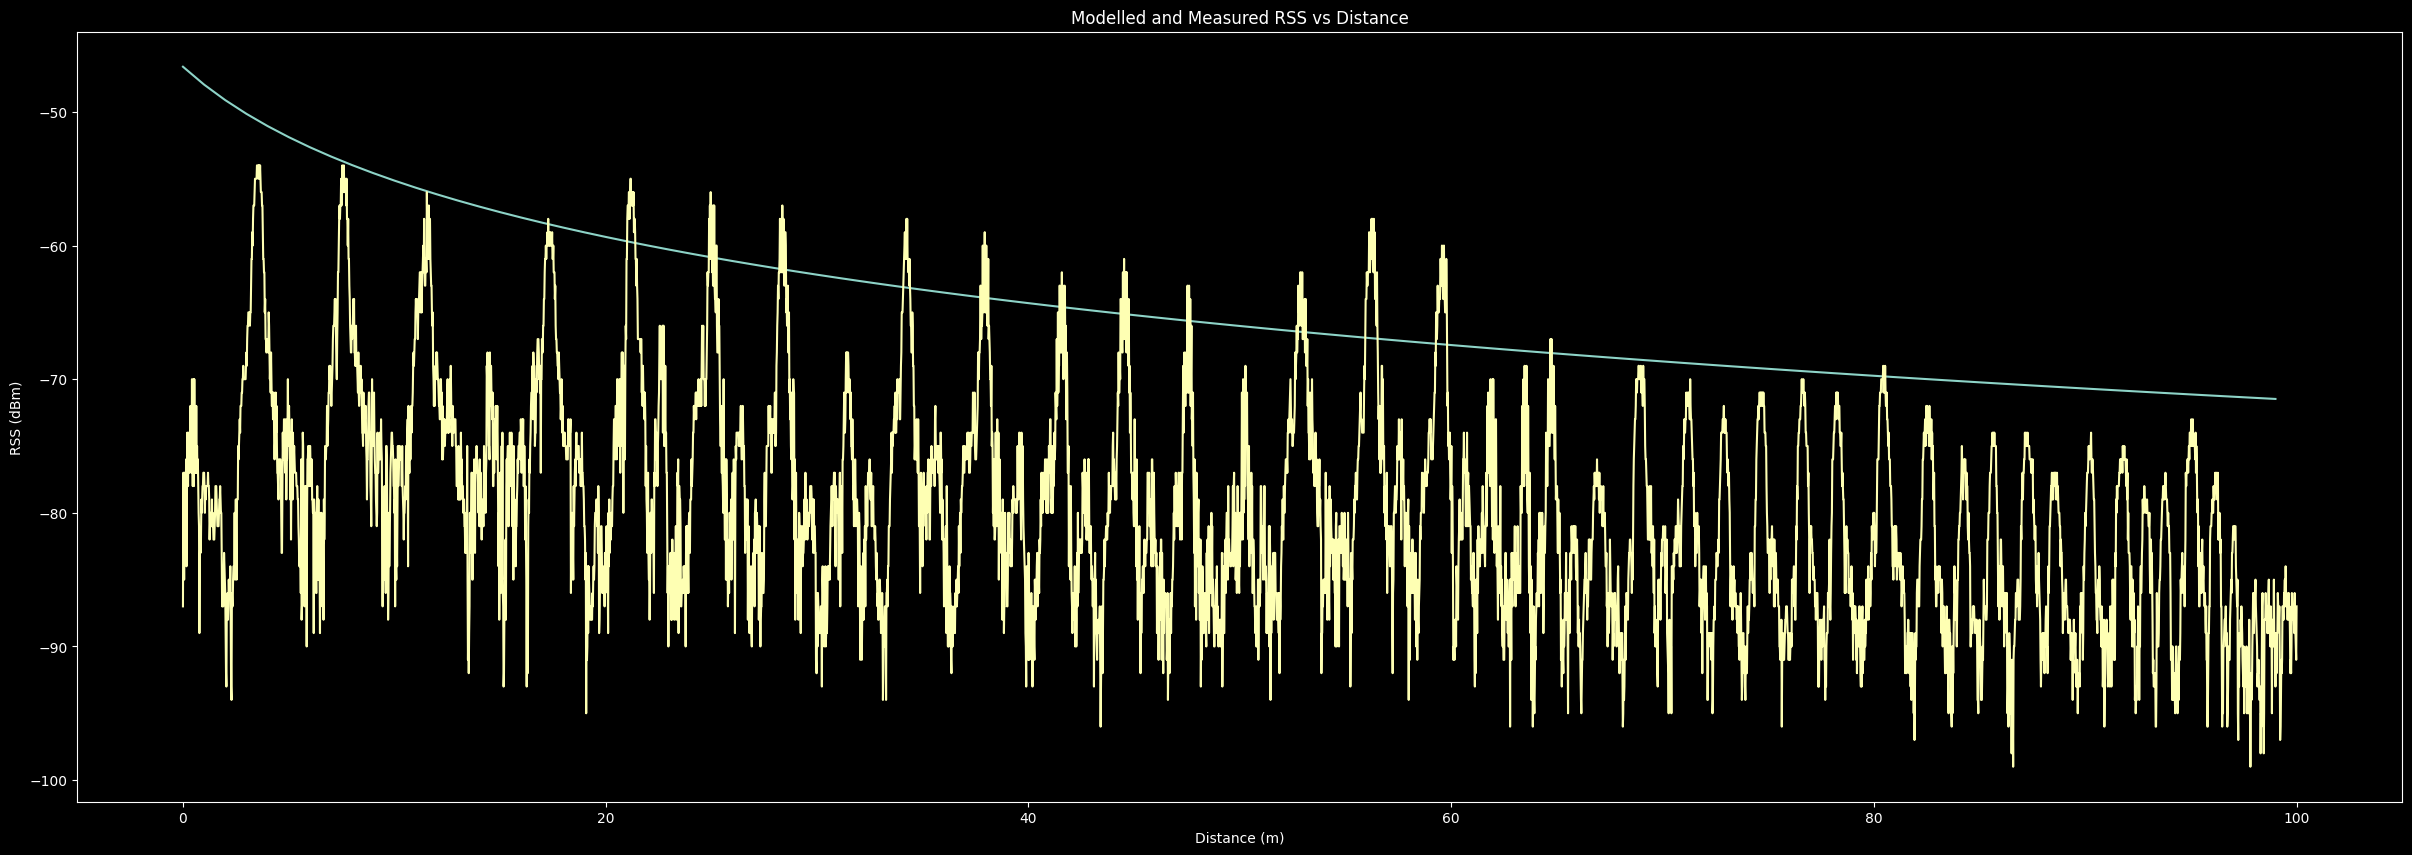

In [57]:
from BLEanalysis.signals import Signals
import numpy as np

transmitter_power = -6 # dBm
dist_travelled = 100 # m
num_data_points = 5400

# generate the model received signal strength
model_points = []

for x in range (6, dist_travelled + 6, 1):
    model_points.append(-1 * signal_loss(x) + transmitter_power)

# plot actual RSS from the tag
straight5_data = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0).data[:num_data_points,0]
tag_x = np.linspace(0, dist_travelled, num_data_points)

# draw the graphs
plt.figure(figsize=(30,10))
plt.plot(model_points)
plt.plot(tag_x, straight5_data)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS vs Distance")
plt.show()